# Modern AI Architectures

## Typical Production Pipeline & Build-vs-Buy Decisions

## What Is a Modern AI Architecture?

A Modern AI Architecture refers to the end-to-end set of technologies, processes, and platforms used to design, build, deploy, monitor, and govern AI systems in real-world environments. Unlike early experimental ML setups that focused only on model training, modern architectures emphasize reliability, scalability, reproducibility, security, and business alignment.

Today’s AI systems are rarely monolithic. Instead, they are composed of loosely coupled layers, each solving a specific concern—data ingestion, feature engineering, model training, inference, monitoring, and governance. This layered architecture allows teams to evolve individual components without breaking the entire system.

A well-designed AI architecture ensures that models do not remain research artifacts but become maintainable, auditable, and revenue-impacting production systems.

## Core Layers of a Modern AI Architecture

A modern AI architecture can be understood as a vertical pipeline with horizontal concerns such as security and governance cutting across all layers.

a) **Data Layer**

This layer handles data ingestion, storage, and access. It includes operational databases, data warehouses, data lakes, and streaming platforms. Modern AI systems increasingly rely on near-real-time data, making streaming systems (Kafka, Pub/Sub, Event Hubs) critical.

b) **Feature & Transformation Layer**

Raw data is rarely suitable for modeling. This layer standardizes transformations, feature calculations, and data validation. Feature stores are often introduced to ensure training–serving consistency.

c) **Model Development Layer**

This is where experimentation happens—model selection, training, evaluation, and hyperparameter tuning. Frameworks such as scikit-learn, PyTorch, TensorFlow, and XGBoost dominate this layer.

d) **Deployment & Serving Layer**

Models are packaged and exposed via APIs or batch jobs. This layer prioritizes latency, scalability, and reliability.

e) **Monitoring & Governance Layer**

Once deployed, models must be continuously monitored for data drift, model drift, bias, latency, and failures, along with compliance and auditability.

## Typical AI Production Pipeline (End-to-End)

A production AI pipeline formalizes the journey from raw data to business decision.

### Step 1: Data Ingestion

Data enters the system from transactional databases, logs, IoT devices, or third-party sources. Production pipelines prioritize automation and validation at this stage.

Key concerns:
* Schema evolution
* Missing or corrupted records
* Late or out-of-order data

### Step 2: Data Processing & Feature Engineering

This step converts raw data into model-ready features. Feature engineering is often the largest source of model performance gains, more impactful than algorithm choice.

Example: Feature preparation using Python

In [1]:
import numpy as np
import pandas as pd

# Create a dummy DataFrame to simulate 'transaction.csv' (a sample dataset of a bank) with some missing values
data = {
    'total_spend': [10000, 60000, 20000, np.nan, 5000, 40000],
    'active_days': [10, 30, 15, 25, np.nan, 20],
    'churn': [0, 1, 0, 1, 0, 0]
}
df = pd.DataFrame(data)
df.head()

,total_spend,active_days,churn
0,10000.0,10.0,0
1,60000.0,30.0,1
2,20000.0,15.0,0
3,NaN,25.0,1
4,5000.0,NaN,0


In [2]:
# Feature engineering
df['avg_spend_per_day'] = df['total_spend'] / df['active_days']
df['is_high_value_customer'] = (df['total_spend'] > 50000).astype(int)

# Handling missing values (now including some np.nan)
df.fillna(0, inplace=True)
df

,total_spend,active_days,churn,avg_spend_per_day,is_high_value_customer
0,10000.0,10.0,0,1000.000000,0
1,60000.0,30.0,1,2000.000000,1
2,20000.0,15.0,0,1333.333333,0
3,0.0,25.0,1,0.000000,0
4,5000.0,0.0,0,0.000000,0
5,40000.0,20.0,0,2000.000000,0


 In production systems, these transformations are versioned and reused to avoid training-serving mismatch.

This code cell demonstrates **Data Processing & Feature Engineering**.

1.  **Dummy DataFrame Creation**: It begins by simulating a `transactions.csv` file by creating a pandas DataFrame with sample data including `total_spend`, `active_days`, and `churn` status.
2.  **Feature Engineering**: Two new features are engineered:
    *   `avg_spend_per_day`: Calculated by dividing `total_spend` by `active_days`.
    *   `is_high_value_customer`: A binary indicator set to 1 if `total_spend` exceeds 50000, and 0 otherwise.
3.  **Missing Value Handling**: It uses `df.fillna(0, inplace=True)` to handle any potential missing values, although the dummy data provided does not have any. This is a common practice in data preprocessing.

### Step 3: Model Training & Evaluation

Models are trained using historical data and evaluated using statistically sound metrics aligned with business objectives.

Example: Training a baseline model

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

X = df.drop('churn', axis =1)
y = df['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Added random_state for reproducibility

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

proba_preds = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print(f'AUC: {roc_auc_score(y_test, proba_preds)}')
print(f'Confusion matrix:\n {confusion_matrix(y_test, y_pred)}')
print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
print(f'Precision: {precision_score(y_test, y_pred, zero_division = 0)}')
print(f'Recall: {recall_score(y_test, y_pred, zero_division = 0)}')
print(f'F1 score: {f1_score(y_test, y_pred, zero_division = 0)}')

AUC: 0.0
Confusion matrix:
 [[1 0]
 [1 0]]
Accuracy: 0.5
Precision: 0.0
Recall: 0.0
F1 score: 0.0


This code cell covers **Model Training & Evaluation**.

1.  **Import Libraries**: It imports necessary modules from `sklearn`: `train_test_split` for data partitioning, `LogisticRegression` for the model, and `roc_auc_score` for evaluation.
2.  **Data Preparation**: Features (`X`) are separated from the target variable (`y`, which is 'churn').
3.  **Train-Test Split**: The data is split into training and testing sets (`X_train`, `X_test`, `y_train`, `y_test`) with a test size of 20%.
4.  **Model Instantiation and Training**: A `LogisticRegression` model is initialized and then trained (`model.fit`) using the training data.
5.  **Prediction and Evaluation**: The trained model predicts probabilities on the test set (`X_test`), and the Area Under the Receiver Operating Characteristic Curve (AUC) score is calculated and printed to evaluate the model's performance.

### Metric Bounds and Interpretation

Understanding the range of values for evaluation metrics is crucial for interpreting model performance:

*   **AUC (Area Under the ROC Curve)**:
    *   **Minimum**: 0.0 (a perfectly bad classifier, always predicting the opposite)
    *   **Maximum**: 1.0 (a perfectly good classifier, distinguishing positive and negative cases flawlessly)
    *   **Random Classifier**: 0.5
    *   **Interpretation**: Higher AUC indicates better discriminatory power.

*   **Precision (Positive Predictive Value)**:
    *   **Minimum**: 0.0 (no correct positive predictions)
    *   **Maximum**: 1.0 (all positive predictions are correct)
    *   **Interpretation**: Measures the accuracy of positive predictions. Crucial when the cost of False Positives is high.

*   **Recall (Sensitivity or True Positive Rate)**:
    *   **Minimum**: 0.0 (no actual positive cases identified)
    *   **Maximum**: 1.0 (all actual positive cases identified)
    *   **Interpretation**: Measures the model's ability to find all positive samples. Crucial when the cost of False Negatives is high.

*   **F1-Score (Harmonic Mean of Precision and Recall)**:
    *   **Minimum**: 0.0 (worst possible score)
    *   **Maximum**: 1.0 (best possible score)
    *   **Interpretation**: Provides a single score that balances Precision and Recall, especially useful when there's an uneven class distribution.

*   **Accuracy**:
    *   **Minimum**: 0.0 (all predictions are wrong)
    *   **Maximum**: 1.0 (all predictions are correct)
    *   **Interpretation**: The proportion of total correct predictions. Can be misleading in imbalanced datasets.

*   **Confusion Matrix**: This is a table, not a single metric with min/max, but its elements (TP, TN, FP, FN) represent counts. The ideal confusion matrix would have large numbers on the main diagonal (TP and TN) and zeros on the off-diagonal (FP and FN).

*   **Feature Importance**: For models like Logistic Regression, coefficients indicate importance. There isn't a strict min/max bound like classification metrics. The *magnitude* of the coefficient indicates the strength of the feature's influence on the prediction, and the *sign* indicates the direction (positive or negative correlation with the target class). Larger absolute values generally mean higher importance.

Actual labels: [0 0 0 1 1 1 0 1 0 0]
Predicted labels: [0 0 1 1 0 1 0 1 0 0]

Confusion Matrix
[[5 1]
 [1 3]]


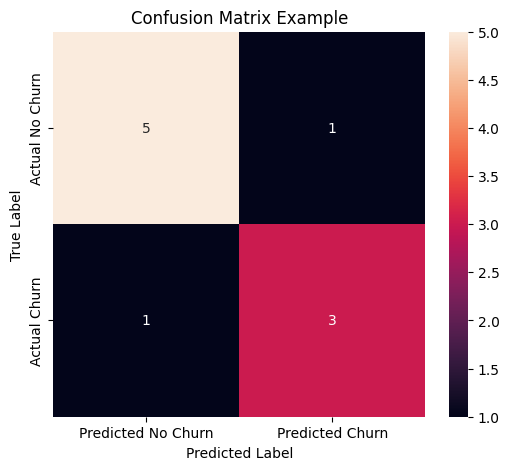

In [49]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Simmulate actual outcomes (0: No churn, 1: Churn)
actual_labels = np.array([0, 0, 0, 1, 1, 1, 0, 1, 0, 0])

# Simulate model predictions (0: Predicted No Churn, 1: Predicted Churn)
predicted_labels = np.array([0, 0, 1, 1, 0, 1, 0, 1, 0, 0])

print(f'Actual labels: {actual_labels}')
print(f'Predicted labels: {predicted_labels}')

# Calculate confusion matrix
cm = confusion_matrix(actual_labels, predicted_labels)

print('\nConfusion Matrix')
print(cm)

# For better understanding, let's visualize it
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Example')
plt.show()

In [50]:
cm[0,0], cm[0,1]

(np.int64(5), np.int64(1))

## Explanation of confusion matrix elements:
* Top-left (cm[0,0]): True Negatives (Correctly predicted No Churn)
* Top-right (cm[0,1]): False Positives (Incorrectly predicted Churn when it was No Churn)
* Bottom-left (cm[1,0]): False Negatives (Incorrectly predicted No Churn when it was Churn)
* Bottom-right (cm[1,1]): True Positives (Correctly predicted Churn)

#### Feature Analysis: Total Spend vs. Churn

To understand which factors might lead to churn, we can visualize the relationship between our engineered features and the `churn` target. Here, we'll look at `total_spend` to see if higher spending customers are more or less likely to churn.

/tmp/ipykernel_2425/2598843157.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='total_spend', data=df, palette='rocket')


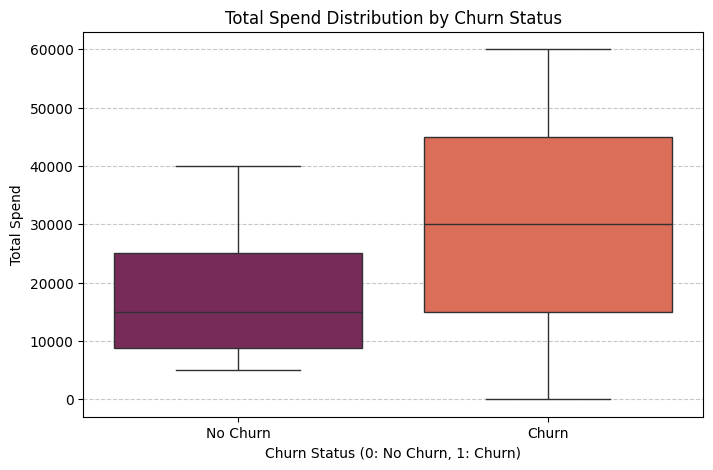

In [51]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='churn', y='total_spend', data=df, palette='rocket')
plt.title('Total Spend Distribution by Churn Status')
plt.xlabel('Churn Status (0: No Churn, 1: Churn)')
plt.ylabel('Total Spend')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Visualizing Model Evaluation Metrics (Conceptual Note)

In a real-world scenario with a sufficiently large test set, we would typically generate several visualizations to evaluate the model's performance beyond just a single metric like AUC.

However, given our very small dummy dataset for demonstration purposes (with only two samples in the test set), such detailed visualizations would not be statistically meaningful or visually informative. They are more applicable when dealing with larger, more realistic datasets.

### Step 4: Model Packaging & Deployment

Trained models are packaged as artifacts and deployed through:

* REST APIs (real-time inference)
* Batch pipelines (offline scoring)
* Streaming inference (near real-time decisions)

Containerization (e.g., Docker) is commonly used to ensure environment consistency.


## 1. What Does Model Packaging Mean?

Model packaging is the process of bundling everything required to run a model into a self-contained unit. This typically includes:
- The trained model file  
- Feature preprocessing logic  
- Model configuration and metadata  
- Library and runtime dependencies  

The objective is to ensure the model behaves exactly the same in production as it did during training and testing.


## 2. Deployment Patterns in Production AI Systems


### a) REST APIs (Real-Time Inference)

In this pattern, the model is exposed as an API endpoint. Applications send input data and receive predictions instantly.

**Typical use cases:**
- Fraud detection during transactions  
- Recommendation systems  
- Credit approval decisions  

**Key characteristics:**
- Low latency requirements  
- Horizontal scalability  
- High availability guarantees  


### b) Batch Pipelines (Offline Scoring)

Batch deployment runs predictions on large datasets at scheduled intervals.

**Typical use cases:**
- Customer churn scoring  
- Demand forecasting  
- Risk segmentation  

**Key characteristics:**
- High throughput  
- Cost efficiency  
- Relaxed latency constraints  


### c) Streaming Inference (Near Real-Time Decisions)

Streaming inference processes data continuously and generates predictions as events arrive.

**Typical use cases:**
- Real-time personalization  
- Anomaly detection  
- Dynamic pricing  

**Key characteristics:**
- Event-driven processing  
- Stateful decision logic  
- Handling late or out-of-order data  


## 3. Why Containerization Is Critical

Containerization packages the model and its environment together, ensuring:
- Consistent runtime behavior  
- Easy portability across environments  
- Faster rollback during failures  

This removes the risk of environment mismatch between development and production.


## 4. Scaling and Reliability Considerations

Production deployments must handle:
- Traffic spikes  
- Instance failures  
- Rolling upgrades without downtime  

Orchestration platforms automatically scale services, manage traffic, and replace unhealthy instances.


## 5. Versioning and Model Lifecycle Management

Models are versioned like software releases. This enables:
- A/B testing  
- Canary deployments  
- Safe rollback  

Versioning ensures traceability of decisions for auditing and debugging.


## 6. Security and Access Control

Deployment introduces security requirements:
- Authentication and authorization  
- Secure data transmission  
- Compliance with organizational policies  

Security reviews are mandatory before production release.




### Step 5: Monitoring, Drift Detection & Feedback Loop

Once live, models are continuously monitored. Production systems treat model degradation as inevitable, not exceptional.

Key monitoring signals:

* Input data distribution shifts
* Prediction confidence changes
* Business KPI impact

Feedback data is fed back into training pipelines, closing the learning loop.

### 1. ROC Curve (Receiver Operating Characteristic Curve) and AUC

**Explanation**: The ROC curve is a fundamental tool for evaluating the performance of a binary classification model across all possible classification thresholds. It plots the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)** at various threshold settings.

*   **TPR (Sensitivity/Recall)**: The proportion of actual positive cases that are correctly identified.
*   **FPR**: The proportion of actual negative cases that are incorrectly identified as positive.

The **Area Under the Curve (AUC)** summarizes the performance across all thresholds, with a value of 1.0 representing a perfect classifier and 0.5 representing a random classifier. A higher AUC generally indicates a better model. It helps to understand how well the model distinguishes between positive and negative classes.

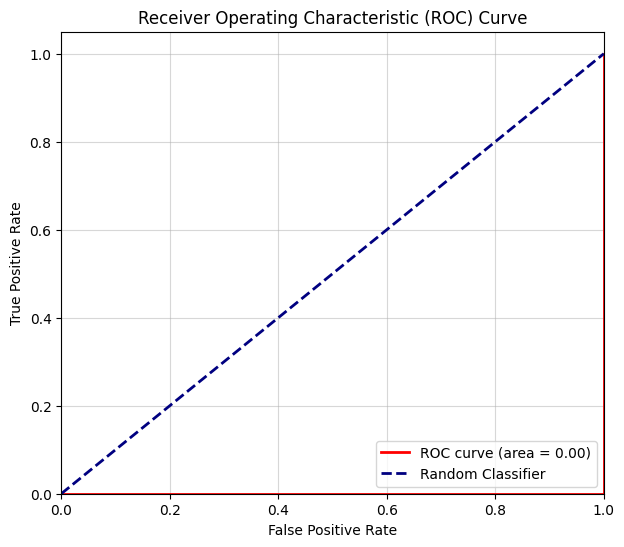

In [53]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Note: Due to the very small test set (2 samples), the ROC curve will look very jagged.
# In a real-world scenario with more test data, it would be smoother.

# Calculate FPR and TPR for various thresholds
fpr, tpr, thresholds = roc_curve(y_test, proba_preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color = 'red', linewidth = 2, label = f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color = 'navy', linewidth = 2, linestyle = '--', label = 'Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha = 0.5)
plt.show()

### 2. Precision-Recall Curve

**Explanation**: The Precision-Recall curve is another useful plot, especially for evaluating models on imbalanced datasets (where one class is much rarer than the other). It shows the trade-off between **Precision** and **Recall** for different probability thresholds.

*   **Precision**: The proportion of positive identifications that were actually correct (TP / (TP + FP)). It measures the model's accuracy on positive predictions.
*   **Recall (Sensitivity)**: The proportion of actual positive cases that were correctly identified (TP / (TP + FN)). It measures the model's ability to find all positive samples.

This curve helps you choose a threshold that balances these two metrics, which is crucial in scenarios where false positives and false negatives have different costs (e.g., medical diagnosis, fraud detection).

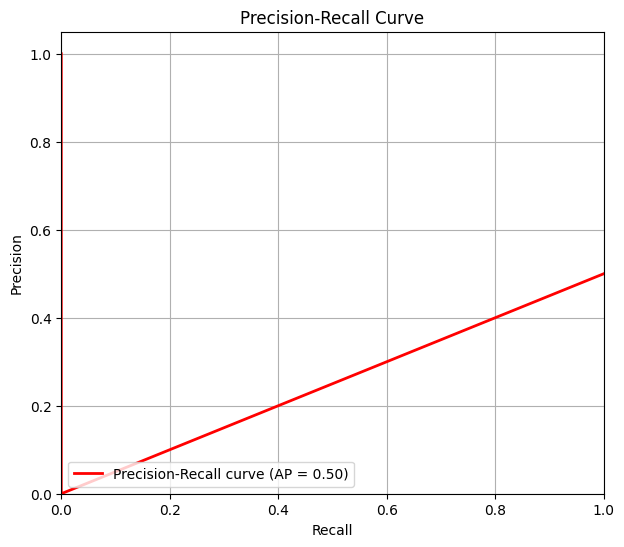

In [55]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Note: Similar to ROC, the curve will be jagged due to the small test set.

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, proba_preds)

# Calculate Average Precision (AP) score
avg_precision = average_precision_score(y_test, y_pred)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, color = 'red', linewidth = 2, label = f'Precision-Recall curve (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True)
plt.show()

### 3. Feature Importance Plots

**Explanation**: Feature importance plots help us understand which input features (variables) contributed most significantly to the model's predictions. This provides valuable insights into the underlying patterns the model learned and can aid in model interpretability and debugging. For a Logistic Regression model, the coefficients associated with each feature can indicate its importance (magnitude and direction of impact).

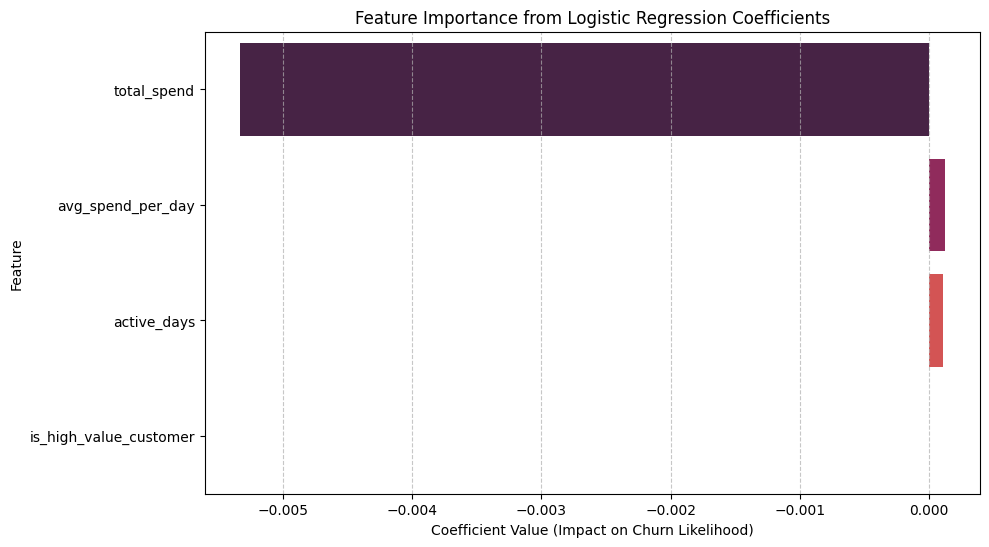

In [58]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# For Logistic Regression, coefficients indicate feature importance.
# The larger the absolute value of the coefficient, the more impactful the feature.

# Ensure model is trained and has coefficients
if hasattr(model, 'coef_'):
  feature_importance = pd.DataFrame({
      'Feature': X_train.columns,
      'Importance': model.coef_[0]
  })
  # Sort by absolute importance to see the most influential features
  feature_importance['Abs_Importance'] = np.abs(feature_importance['Importance'])
  feature_importance = feature_importance.sort_values(by = 'Abs_Importance', ascending = False)

  plt.figure(figsize=(10, 6))

  # Fix for Future Warning: Assign the `y` variable to `hue` and set `legend=False`
  sns.barplot(x = 'Importance', y = 'Feature', data = feature_importance, palette = 'rocket', hue = 'Feature', legend = False)
  plt.title('Feature Importance from Logistic Regression Coefficients')
  plt.xlabel('Coefficient Value (Impact on Churn Likelihood)')
  plt.ylabel('Feature')
  plt.grid(axis='x', linestyle='--', alpha=0.7)
  plt.show()
else:
  print("Model does not have 'coef_' attribute (e.g., if not a linear model or not yet fitted).")

The next code cell illustrates **Model Packaging & Deployment** by demonstrating how a trained model makes predictions.

1.  **Simulate New Data**: It creates a copy of `X_test` to simulate new, unseen data that a deployed model would receive for inference.
2.  **Predict Probabilities**: The `model.predict_proba()` method is used to get the probability of each class (churn or no churn) for the simulated new data. We select the probability of the positive class (churn).
3.  **Predict Binary Outcomes**: The `model.predict()` method is used to get the final binary predictions (0 or 1) based on the model's decision threshold.
4.  **Display Results**: The code prints the sample new data, the predicted probabilities, and the binary predictions. This output mimics what would be returned by an API endpoint or written to a database in a real-world production system.

### Demonstrating Model Deployment: Making Predictions

After a model is trained and evaluated, it's ready for deployment. A core aspect of deployment is serving the model to make predictions on new, unseen data. Here, we'll use our trained `LogisticRegression` model to predict churn probabilities on the test set.

In [63]:
# Simulate making predictions with the deployed model
# In a real deployment, 'new_data' would come from an API request or a batch job.

new_data_for_pred = X_test.copy()

# Get churn probabilities for the new data
prediction_proba = model.predict_proba(new_data_for_pred)[:, 1]

# Get binary predictions (e.g., 0 or 1)
pred_binary = model.predict(new_data_for_pred)

print("Sample of new data for prediction:")
print(new_data_for_pred.head())
print("\nPredicted churn probabilities:")
print(prediction_proba)
print("\nPredicted churn (binary):")
print(pred_binary)

Sample of new data for prediction:
   total_spend  active_days  avg_spend_per_day  is_high_value_customer
0      10000.0         10.0             1000.0                       0
1      60000.0         30.0             2000.0                       1

Predicted churn probabilities:
[3.38511425e-018 7.37770143e-134]

Predicted churn (binary):
[0 0]


In a production system, these predictions would be returned via an API endpoint or written to a database.

## Build vs Buy: A Strategic Decision

One of the most critical decisions in designing an AI stack is whether to build components in-house or buy managed services.

This decision is strategic, not technical.

### Build Approach (Custom Stack)

**What It Means**

The organization develops and maintains most components internally using open-source tools.

**Advantages**

* Full control over architecture and data
* Maximum customization
* Avoids vendor lock-in
* Deep internal ML capability building

**Challenges**

* High engineering and maintenance cost
* Longer time to market
* Requires strong MLOps maturity
* Operational risk lies entirely with the team

**When to Build**

* AI is a core competitive differentiator
* Regulatory or data residency constraints exist
* Organization has mature ML and platform teams

### Buy Approach (Managed / Platform Services)

**What It Means**

The organization uses cloud-managed or SaaS AI platforms for training, deployment, or monitoring.

**Advantages**

* Faster experimentation and deployment
* Reduced operational overhead
* Built-in scalability, security, and compliance
* Lower initial cost

**Challenges**

* Limited customization
* Vendor lock-in risk
* Less transparency into internals
* Cost may grow at scale

**When to Buy**

* Faster time-to-value is critical
* AI is an enabler, not the core product
* Team size or expertise is limited

### Hybrid Strategy (Most Common in Practice)

Most enterprises adopt a hybrid model:

* Buy infrastructure, orchestration, and monitoring
* Build feature logic and models

**Example:**

* Buy: Cloud ML platform, model registry, monitoring
* Build: Feature engineering, custom models, decision logic

This approach balances speed, control, and cost.

## Key Architectural Trade-Offs

| Dimension | Build | Buy |
|---|---|---|
| Time to market | Slow | Fast |
| Customization | High | Medium |
| Cost predictability | Medium | Low at scale |
| Talent requirement | High | Medium |
| Vendor lock-in | Low | High |

## Key Takeaways for Learners

* Modern AI architectures focus as much on operations and governance as on models.
* Production pipelines are repeatable systems, not one-time scripts.
* Feature engineering and monitoring matter more than algorithm choice in production.
* Build vs Buy is a business decision supported by technical reasoning, not the other way around.
* Most real-world systems succeed with a hybrid AI stack.

## Cloud Perspective on Modern AI Architectures (Enterprise View)

Modern AI architectures are rarely built on bare infrastructure. Cloud platforms provide managed building blocks that map cleanly to each stage of the AI production pipeline. Understanding this mapping helps teams make informed build-vs-buy decisions while designing scalable systems.

### 10.1 Cloud Mapping of a Typical AI Production Pipeline

a) **Data Ingestion & Storage (Cloud-Native)**

Cloud platforms provide fully managed ingestion and storage services that reduce operational burden.

**Common Patterns**

* Batch ingestion from operational databases
* Streaming ingestion for real-time AI use cases
* Separation of raw, curated, and feature-ready data zones

**Examples**

* AWS: S3 (Data Lake), Kinesis, Glue
* Azure: Azure Data Lake Gen2, Event Hubs, Data Factory
* GCP: Cloud Storage, Pub/Sub, Dataflow

Cloud-managed storage enables:

* Elastic scaling
* Schema evolution
* Cost-efficient tiered storage

b) **Feature Engineering & Transformation (Cloud Scale)**

In cloud-based architectures, feature engineering often runs as distributed jobs rather than local scripts.

**Key Capabilities**

* Distributed processing
* Reusable transformation pipelines
* Feature consistency between training and serving

**Examples**

* AWS: Glue, EMR, SageMaker Feature Store
* Azure: Synapse, Azure ML Feature Store
* GCP: Dataflow, BigQuery ML features, Vertex AI Feature Store

Python-based feature logic is typically containerized and executed on managed compute, not local machines.

c) **Model Training (Managed Compute)**

Cloud platforms abstract away infrastructure provisioning for model training.

**Key Advantages**

* Auto-scaling GPU/CPU clusters
* Spot/preemptible instances for cost optimization
* Distributed training support

**Examples**

* AWS: SageMaker Training Jobs
* Azure: Azure Machine Learning Compute Clusters
* GCP: Vertex AI Training

From a curriculum perspective, learners must understand that:

* The same Python training code runs locally for experimentation and on cloud clusters for scale.

d) **Model Registry & Experiment Tracking (Cloud-Managed)**

Cloud platforms provide centralized model registries and experiment tracking.

**Capabilities**

* Model versioning
* Metadata storage
* Approval workflows
* Lineage tracking

**Examples**

* AWS: SageMaker Model Registry
* Azure: Azure ML Model Registry
* GCP: Vertex AI Model Registry

This is a buy vs build inflection point—most enterprises prefer buying this layer.

e) **Deployment & Serving (Cloud-Native Inference)**

Cloud AI architectures support multiple inference patterns:

* Real-time APIs
* Batch inference
* Streaming inference

**Examples**

* AWS: SageMaker Endpoints, Lambda + API Gateway
* Azure: Azure ML Endpoints, AKS-based deployments
* GCP: Vertex AI Endpoints, Cloud Run

Cloud-managed serving provides:

* Auto-scaling
* Traffic splitting (A/B testing)
* Canary deployments

f) **Monitoring, Drift & Governance (Cloud + MLOps)**

Monitoring is where cloud platforms deliver maximum operational value.

**Monitored Signals**

* Input feature drift
* Prediction drift
* Latency and error rates
* Business KPI degradation

**Examples**

* AWS: CloudWatch + SageMaker Model Monitor
* Azure: Azure Monitor + Responsible AI dashboards
* GCP: Vertex AI Model Monitoring

Governance features support:

* Audit trails
* Compliance reporting
* Responsible AI requirements

### 10.2 Cloud Influence on Build vs Buy Decisions

Cloud platforms shift the economics of AI stack decisions.

**What Teams Commonly Buy on Cloud**

* Compute orchestration
* Model registries
* Deployment infrastructure
* Monitoring and alerting

**What Teams Still Build**

* Feature logic
* Custom models
* Business-specific decision layers
* Domain-specific evaluation metrics

This reinforces the hybrid strategy described earlier.